# 1. ML Problem Definition

Objective

Predict whether a transaction is:

0 → Legitimate transaction
1 → Fraudulent transaction

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

# 2. LOAD DATA CLEAN DATA

In [59]:
df = pd.read_csv("C:/Users/Asus/OneDrive/Desktop/Major_Project/paysim_final.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,errorBalanceOrg,errorBalanceDest,isMerchantDest,amount_to_org_balance,hour,day,time_period,large_transaction,balance_utilization
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,0.0,9839.64,1,0.057834,1,0,Night,0,<25%
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,0.0,1864.28,1,0.087735,1,0,Night,0,<25%
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,0.0,181.00,0,1.000000,1,0,Night,0,75-100%
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,0.0,-21001.00,0,1.000000,1,0,Night,0,75-100%
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,0.0,11668.14,1,0.280795,1,0,Night,0,25-50%


In [60]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud', 'errorBalanceOrg', 'errorBalanceDest',
       'isMerchantDest', 'amount_to_org_balance', 'hour', 'day', 'time_period',
       'large_transaction', 'balance_utilization'],
      dtype='object')

In [61]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [62]:
df["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [63]:
df.shape

(6362620, 20)

In [64]:
df.isnull().sum().sum()

np.int64(0)

In [65]:
df["isFraud"].value_counts()[1]

np.int64(8213)

In [66]:
df["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [67]:
df.isnull().sum()

step                     0
type                     0
amount                   0
nameOrig                 0
oldbalanceOrg            0
newbalanceOrig           0
nameDest                 0
oldbalanceDest           0
newbalanceDest           0
isFraud                  0
isFlaggedFraud           0
errorBalanceOrg          0
errorBalanceDest         0
isMerchantDest           0
amount_to_org_balance    0
hour                     0
day                      0
time_period              0
large_transaction        0
balance_utilization      0
dtype: int64

In [68]:
df.shape

(6362620, 20)

In [69]:
(df["isFraud"].value_counts()[1] / df.shape[0]) *100

np.float64(0.12908204481801522)

# 3. EDA in ML

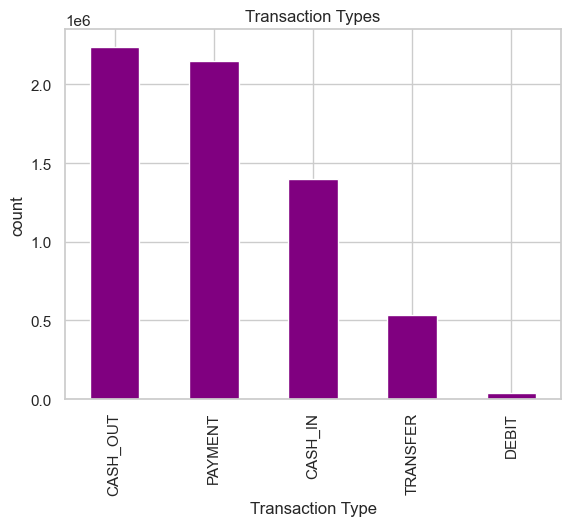

In [70]:
df["type"].value_counts().plot(kind = "bar", title = "Transaction Types", color = "purple")
plt.xlabel("Transaction Type")
plt.ylabel("count")
plt.show()

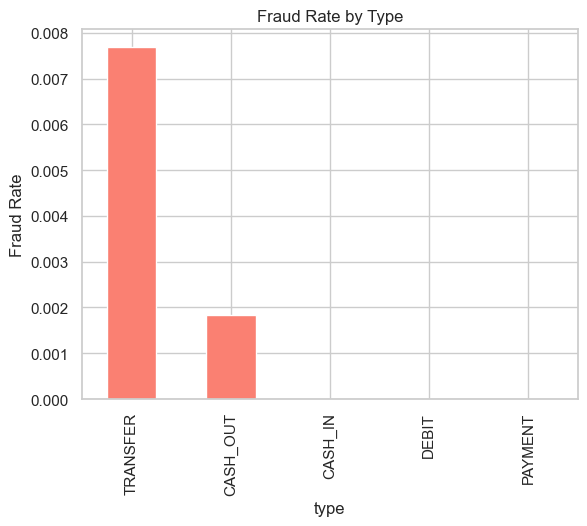

In [71]:
fraud_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)
fraud_by_type.plot(kind="bar", title = "Fraud Rate by Type",color = "salmon")
plt.ylabel("Fraud Rate")
plt.show()
                   

In [72]:
fraud_by_type

type
TRANSFER    0.007688
CASH_OUT    0.001840
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64

In [73]:
df["amount"].describe().astype(int)

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int64

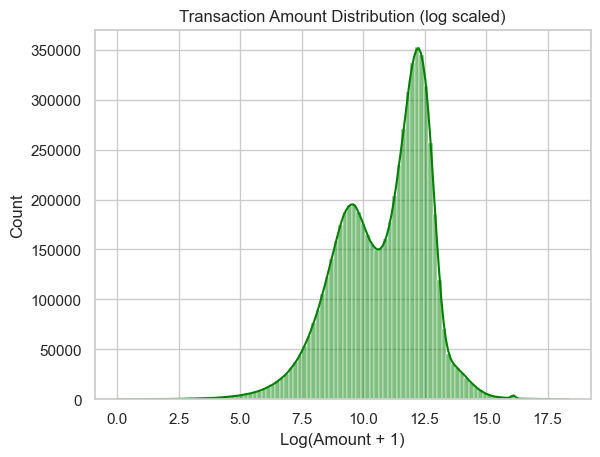

In [74]:
sns.histplot(np.log1p(df["amount"]),bins=100,kde = True, color = "green")
plt.title("Transaction Amount Distribution (log scaled)")
plt.xlabel("Log(Amount + 1)")
plt.show()            

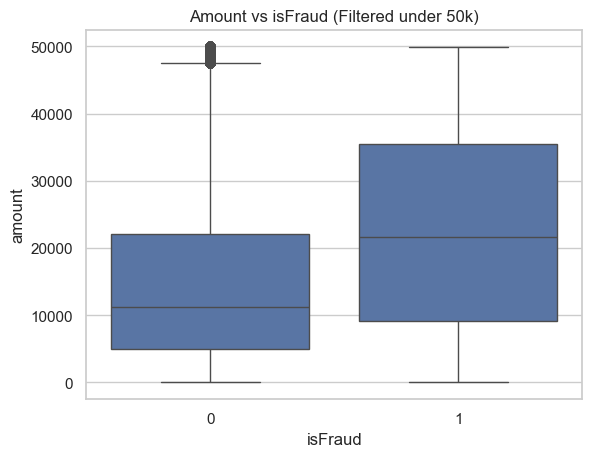

In [75]:
sns.boxplot(data = df[df["amount"] < 50000], x = "isFraud", y = "amount")
plt.title("Amount vs isFraud (Filtered under 50k)")
plt.show()

In [76]:
df["balanceDiffOrig"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["balanceDiffDest"] = df["newbalanceDest"] - df["oldbalanceDest"]

In [77]:
(df["balanceDiffOrig"] < 0).sum()

np.int64(1399253)

In [78]:
(df["balanceDiffDest"] < 0).sum()

np.int64(1238864)

In [79]:
df.head(2)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,...,errorBalanceDest,isMerchantDest,amount_to_org_balance,hour,day,time_period,large_transaction,balance_utilization,balanceDiffOrig,balanceDiffDest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,...,9839.64,1,0.057834,1,0,Night,0,<25%,9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,...,1864.28,1,0.087735,1,0,Night,0,<25%,1864.28,0.0


In [80]:
print(df.columns.tolist())

['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'errorBalanceOrg', 'errorBalanceDest', 'isMerchantDest', 'amount_to_org_balance', 'hour', 'day', 'time_period', 'large_transaction', 'balance_utilization', 'balanceDiffOrig', 'balanceDiffDest']


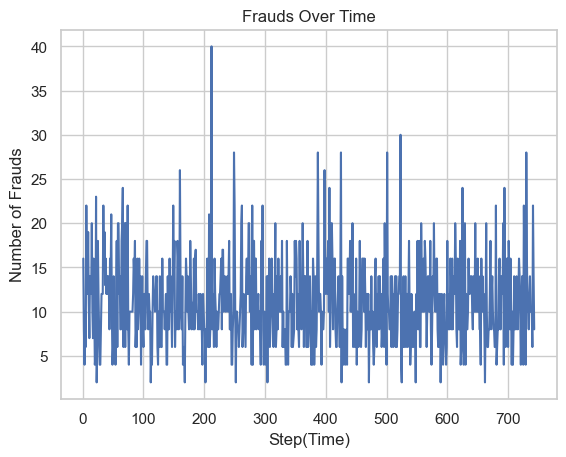

In [81]:
frauds_per_step = df[df["isFraud"] == 1]["step"].value_counts().sort_index()
plt.plot(frauds_per_step.index , frauds_per_step.values, label = "Frauds per Step")
plt.xlabel("Step(Time)")
plt.ylabel("Number of Frauds")
plt.title("Frauds Over Time")
plt.grid(True)
plt.show()

In [82]:
print(df.columns.tolist())

['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'errorBalanceOrg', 'errorBalanceDest', 'isMerchantDest', 'amount_to_org_balance', 'hour', 'day', 'time_period', 'large_transaction', 'balance_utilization', 'balanceDiffOrig', 'balanceDiffDest']


In [83]:
print(df.head())

   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  ...  \
0  M1979787155             0.0             0.0        0  ...   
1  M2044282225             0.0             0.0        0  ...   
2   C553264065             0.0             0.0        1  ...   
3    C38997010         21182.0             0.0        1  ...   
4  M1230701703             0.0             0.0        0  ...   

   errorBalanceDest  isMerchantDest  amount_to_org_balance  hour  day  \
0           9839.64               1               0.057834     1    0   
1           1864.2

In [84]:
df.drop(columns = "step",inplace=True)

In [85]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,...,errorBalanceDest,isMerchantDest,amount_to_org_balance,hour,day,time_period,large_transaction,balance_utilization,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,...,9839.64,1,0.057834,1,0,Night,0,<25%,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,...,1864.28,1,0.087735,1,0,Night,0,<25%,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,...,181.00,0,1.000000,1,0,Night,0,75-100%,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,...,-21001.00,0,1.000000,1,0,Night,0,75-100%,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,...,11668.14,1,0.280795,1,0,Night,0,25-50%,11668.14,0.0


In [86]:
top_senders = df["nameOrig"].value_counts().head(10)

In [87]:
top_senders

nameOrig
C1902386530    3
C363736674     3
C545315117     3
C724452879     3
C1784010646    3
C1677795071    3
C1462946854    3
C1999539787    3
C2098525306    3
C400299098     3
Name: count, dtype: int64

In [88]:
top_receivers = df["nameDest"].value_counts().head(10)

In [89]:
top_receivers

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C451111351      99
C1789550256     99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

In [91]:
fraud_users = df[df["isFraud"]==1]["nameOrig"].value_counts().head(10)

In [92]:
fraud_users

nameOrig
C1305486145    1
C755286039     1
C973279667     1
C258213312     1
C1640703547    1
C1127265876    1
C317779855     1
C1064034527    1
C1141104763    1
C1966863341    1
Name: count, dtype: int64

In [93]:
fraud_types = df[df["type"].isin(["TRANSFER","CASH_OUT"])]

In [94]:
fraud_types["type"].value_counts()

type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64

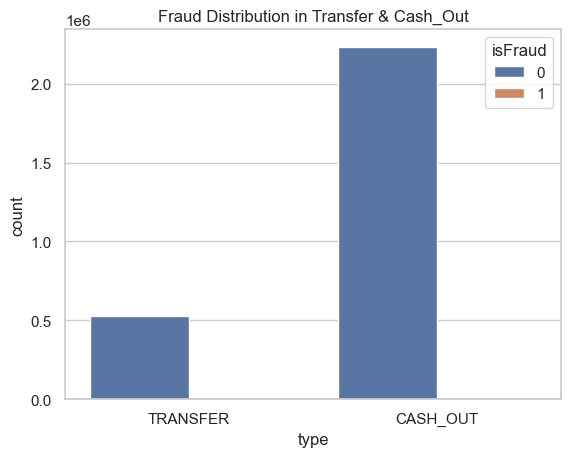

In [96]:
sns.countplot(data=fraud_types , x="type" , hue = "isFraud")
plt.title("Fraud Distribution in Transfer & Cash_Out")
plt.show()

In [98]:
corr = df[["amount","oldbalanceOrg","newbalanceOrig","oldbalanceDest", "newbalanceDest", "isFraud"]].corr()


In [99]:
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535
isFraud,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000


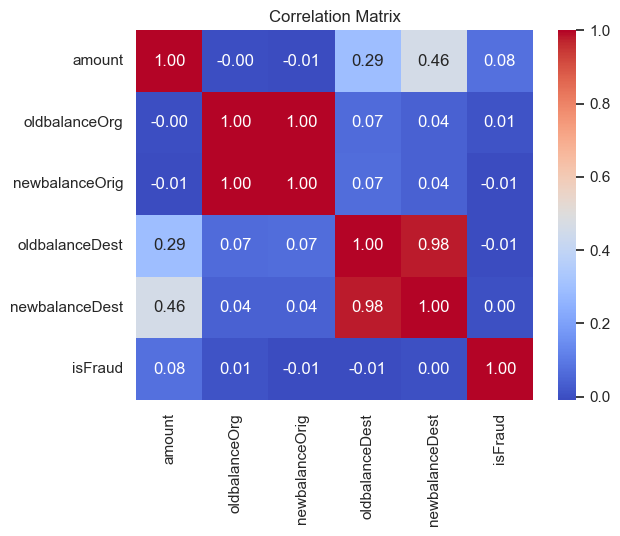

In [103]:
sns.heatmap(corr,annot=True,cmap = "coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [104]:
zero_after_transfer = df[
    (df["oldbalanceOrg"] > 0) &
    (df["newbalanceOrig"] == 0) &
    (df["type"].isin(["TRANSFER","CASH_OUT"]))
    ]

In [105]:
len(zero_after_transfer)

1188074

In [106]:
zero_after_transfer.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,...,errorBalanceDest,isMerchantDest,amount_to_org_balance,hour,day,time_period,large_transaction,balance_utilization,balanceDiffOrig,balanceDiffDest
2,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,...,181.00,0,1.000000,1,0,Night,0,75-100%,181.0,0.00
3,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,...,-21001.00,0,1.000000,1,0,Night,0,75-100%,181.0,-21182.00
15,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,...,275564.38,0,14.951644,1,0,Night,0,>100%,15325.0,46430.44
19,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,...,192885.30,0,305.404677,1,0,Night,0,>100%,705.0,-22425.00
24,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,...,3024591.78,0,28.766580,1,0,Night,0,>100%,10835.0,2712905.89


In [107]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

# 4. Feature Engineering Training a ML model

In [110]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


In [111]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,...,errorBalanceDest,isMerchantDest,amount_to_org_balance,hour,day,time_period,large_transaction,balance_utilization,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,...,9839.64,1,0.057834,1,0,Night,0,<25%,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,...,1864.28,1,0.087735,1,0,Night,0,<25%,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,...,181.00,0,1.000000,1,0,Night,0,75-100%,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,...,-21001.00,0,1.000000,1,0,Night,0,75-100%,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,...,11668.14,1,0.280795,1,0,Night,0,25-50%,11668.14,0.0


In [112]:
df_model = df.drop(["nameOrig","nameDest", "isFlaggedFraud"], axis = 1)

In [113]:
df_model.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,errorBalanceOrg,errorBalanceDest,isMerchantDest,amount_to_org_balance,hour,day,time_period,large_transaction,balance_utilization,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,0.0,9839.64,1,0.057834,1,0,Night,0,<25%,9839.64,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,0.0,1864.28,1,0.087735,1,0,Night,0,<25%,1864.28,0.0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,0.0,181.00,0,1.000000,1,0,Night,0,75-100%,181.00,0.0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,0.0,-21001.00,0,1.000000,1,0,Night,0,75-100%,181.00,-21182.0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,0.0,11668.14,1,0.280795,1,0,Night,0,25-50%,11668.14,0.0


In [115]:
categorical = ["type"]
numeric = ["amount","oldbalanceOrg","newbalanceOrig", "oldbalanceDest", "newbalanceDest"]

In [116]:
y = df_model["isFraud"]
x = df_model.drop("isFraud", axis = 1)

In [118]:
X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=0.3, stratify=y)

In [121]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical)
    ],
    remainder="drop"
)

In [122]:
pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000))
])

In [123]:
pipeline.fit(X_train, y_train)

,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [124]:
y_pred = pipeline.predict(X_test)

In [125]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1906322
           1       0.02      0.94      0.04      2464

    accuracy                           0.95   1908786
   macro avg       0.51      0.94      0.51   1908786
weighted avg       1.00      0.95      0.97   1908786



In [126]:
confusion_matrix(y_test,y_pred)

array([[1802246,  104076],
       [    153,    2311]])

In [127]:
y_pred = pipeline.predict(X_test)

In [128]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1906322
           1       0.02      0.94      0.04      2464

    accuracy                           0.95   1908786
   macro avg       0.51      0.94      0.51   1908786
weighted avg       1.00      0.95      0.97   1908786



In [129]:
confusion_matrix(y_test, y_pred)

array([[1802246,  104076],
       [    153,    2311]])

In [134]:
pipeline.score(X_test, y_test)*100

94.53951359660014

In [135]:
import joblib
joblib.dump(pipeline,"fraud_detection_pipeline.pkl")

['fraud_detection_pipeline.pkl']